# Unemployment Trends Across California Counties 

## Purpose 
The purpose of this notebook is to analyze county level unemployment trends over time usinig the cleaned labor force dataset. The goal is to idenitfy long term patterns, regional differences, and notable changes across economic periods. 

In [1]:
#Import Data
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../data/cleaned/california_county_unemployment_cleaned.csv"
df = pd.read_csv(file_path)

In [2]:
#Confirmation
df.head()

,area_name,area_type,year,month,seasonally_adjusted(y/n),status,labor_force,employment,unemployment,unemployment_rate
0,Alameda County,County,1990,Annual,N,Final,678000,650600,27500,4.0
1,Alameda County,County,1991,Annual,N,Final,672500,635600,36900,5.5
2,Alameda County,County,1992,Annual,N,Final,677000,632300,44800,6.6
3,Alameda County,County,1993,Annual,N,Final,677300,632000,45300,6.7
4,Alameda County,County,1994,Annual,N,Final,679000,636900,42100,6.2


In [3]:
# Yearly Average Unemployment

state_trend = (
    df.groupby('year')['unemployment_rate']
    .mean()
    .reset_index()
)

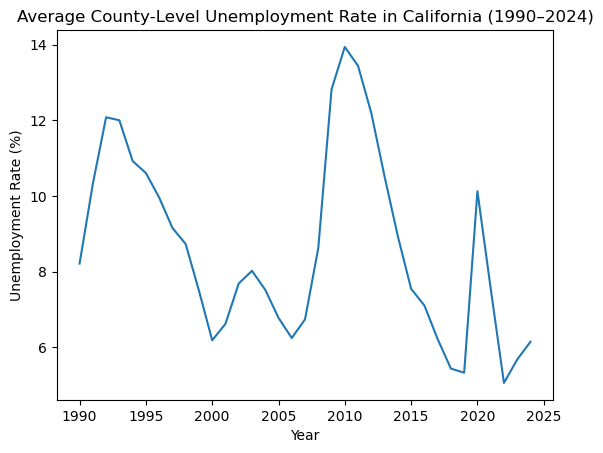

In [10]:
# Plot
plt.figure()
plt.plot(state_trend['year'], state_trend['unemployment_rate'])
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.title('Average County-Level Unemployment Rate in California (1990–2024)')
plt.show()

# Observations
- The average unemployment rate fluctuates over time, reflecting major economic cycles. 
- Spikes are visible during known recession periods (1990's recession, 2001 Tech company market collapse, 2007 Great Recession, 2020 Covid Recession. )
- Post recession speed recovery varies in speed and magnitude. 

In [11]:
# County Selection
key_counties = [
    'Los Angeles County',
    'San Diego County',
    'Santa Clara County',
    'San Francisco County',
    'Fresno County'
]

In [20]:
df_county = df[df['area_type'] == 'County']

In [21]:
df_county.columns

Index(['area_name', 'area_type', 'year', 'month', 'seasonally_adjusted(y/n)',
       'status', 'labor_force', 'employment', 'unemployment',
       'unemployment_rate'],
      dtype='object')

In [22]:
#Filter
df_selected = df_county[df_county['area_name'].isin(key_counties)]

In [ ]:
#Check
df_selected['area_name'].unique()

array(['Fresno County', 'Los Angeles County', 'San Diego County',
       'San Francisco County', 'Santa Clara County'], dtype=object)

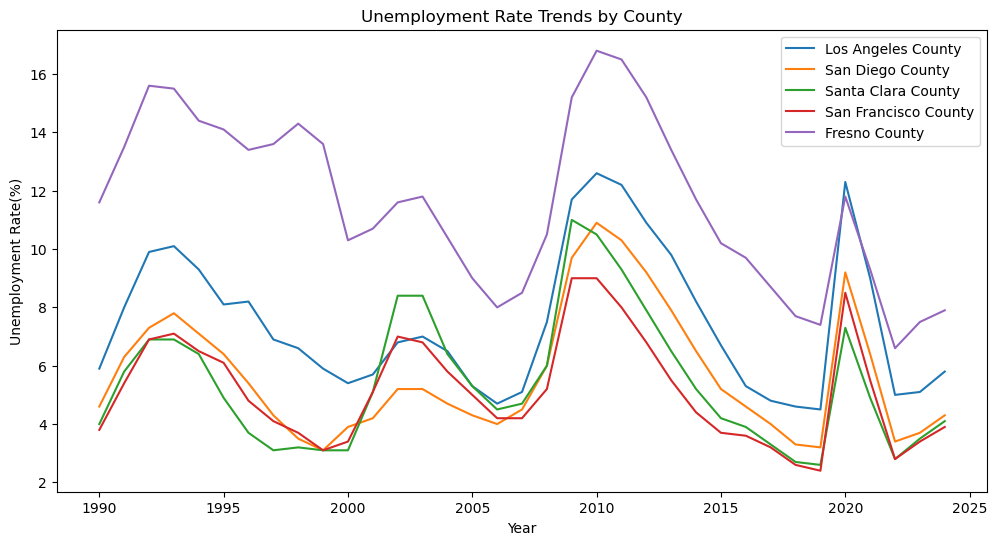

In [25]:
#Plot Unemployment Trend (Following Steps)
plt.figure(figsize=(12,6))

for county in key_counties: 
    county_data = df_selected[df_selected['area_name'] == county]
    plt.plot(
        county_data['year'],
        county_data['unemployment_rate'],
        label=county
    )

plt.title('Unemployment Rate Trends by County')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate(%)')
plt.legend()
plt.show()

# County Level Comparison 
- While all selected counties experience increases in unemployment during recessions, the magnitude and recovery patterns differ. 
- The COVID-19 recession impacted all counties simultaneously, though recovery speeds vary by region. 
- Technology focused counties such as Santa Clara and San Francisco show a quicker recovery during the tech company crash, while agricultural regions like Fresno show different recovery dynamics. 

In [ ]:
# Counties with the highest unemployment rate ever recorded
peak_unemployment = (
    df_county
    .groupby('area_name')['unemployment_rate']
    .max()
    .sort_values(ascending = False)
)

peak_unemployment.head(10)

area_name
Imperial County      30.9
Colusa County        21.7
Sutter County        19.7
Glenn County         19.1
Plumas County        18.4
Tulare County        18.3
Merced County        18.1
Yuba County          17.9
Trinity County       17.4
San Benito County    17.4
Name: unemployment_rate, dtype: float64

In [28]:
#Table
peak_unemployment_df = peak_unemployment.reset_index()
peak_unemployment_df.columns = ['county', 'peak_unemployment_rate']

In [35]:
peak_unemployment_df

,county,peak_unemployment_rate
0,Imperial County,30.9
1,Colusa County,21.7
2,Sutter County,19.7
3,Glenn County,19.1
4,Plumas County,18.4
5,Tulare County,18.3
6,Merced County,18.1
7,Yuba County,17.9
8,Trinity County,17.4
9,San Benito County,17.4


In [33]:
#peak year
peak_year = (
    df_county
    .loc[df_county.groupby('area_name')['unemployment_rate'].idxmax()]
    [['area_name','year','unemployment_rate']]
    .rename(columns ={
        'area_name' : 'county',
        'year': 'peak_year',
        'unemployment_rate':'peak_unemployment_rate'
    })
)

In [34]:
peak_year

,county,peak_year,peak_unemployment_rate
20,Alameda County,2010,11.0
37,Alpine County,1992,16.7
90,Amador County,2010,14.2
125,Butte County,2010,14.0
160,Calaveras County,2010,14.6
177,Colusa County,1992,21.7
230,Contra Costa County,2010,11.1
247,Del Norte County,1992,15.5
300,El Dorado County,2010,12.3
335,Fresno County,2010,16.8


# Peak Unemployment By County 
- Counties show significant variance in their peak unemployment rates. 
- Many counties reached their highest levels of unemployment during the Great Recession (2007-2009)
- Highlighting on the county differences when it comes to recovery capabilities. 

In [36]:
# Top 10 Counties by Peak Unemployment

top_10 = peak_unemployment_df.sort_values(
    by='peak_unemployment_rate',
    ascending=False
).head(10)

<function matplotlib.pyplot.show(close=None, block=None)>

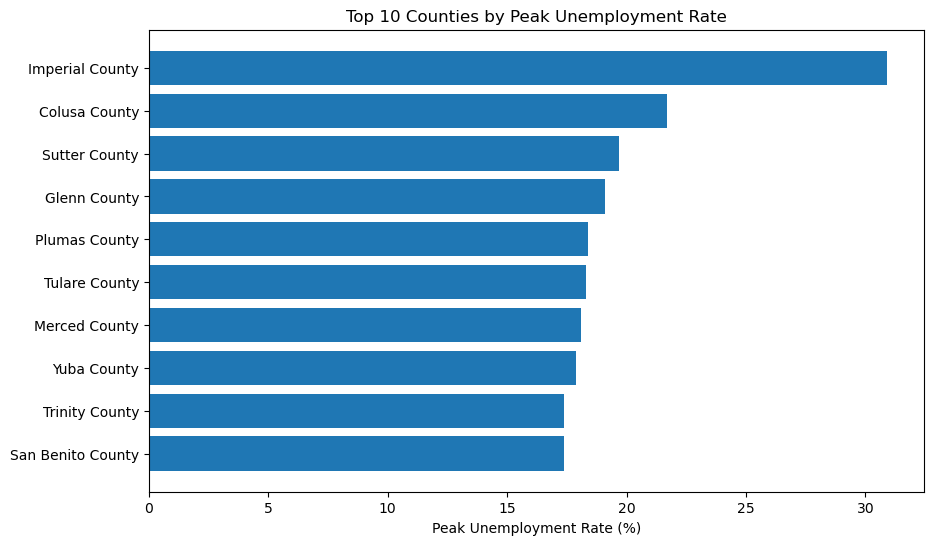

In [37]:
# Bar Chart
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
plt.barh(
    top_10['county'],
    top_10['peak_unemployment_rate']
)
plt.xlabel('Peak Unemployment Rate (%)')
plt.title('Top 10 Counties by Peak Unemployment Rate')
plt.gca().invert_yaxis()
plt.show

## Counties Most Impacted by Unemployment
- The chart above highlights counties with the highest recorded unemployment rates from the time frame (1990-2024)
- Many of the affected counties suffered with their employment due to their economic structure, or in other words, counties that heavily rely on agriculture, tourism, or construction experienced higher unemployment rates during recessions. 

# Conclusion

The project conducted examined county level unemployment trends over time (1990-2024), specifically looking at how major economic recesssions have influenced regional labor markets differently. During the time frame, there were three significant recessionary periods that occured, which include the 1990s recession, the Great recession, and the COVID-19 pandemic, where spikes in unemployment are noticeable. 

When looking closer at the county level, comparisons between the unemployment rates show variation in the recovery speeds and severity of the unemployment spikes.Ultimately, it conveys that counties with a more diverse economy recovered more quickly, and did not suffer as much as counties that rely more heavily on tourism, agriculture, and construction. 

Overall, the findings emphasize the importance of regional economic structure when it comes to shaping the labor market, especially when it comes to periods of recession. 